In [3]:
#import packages
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import os
import yaml
import itertools
import shutil
from datetime import datetime
from pathlib import Path
from openpyxl.styles import PatternFill
from openpyxl import load_workbook
from collections import defaultdict
import sys
from openpyxl.styles import Border, Side
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter
from numpy._core.numeric import indices
from tqdm import tqdm
from functools import lru_cache
from collections import deque
import networkx as nx
from collections import Counter


#set working dir
os.chdir("/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project")

In [ ]:
# load cores
project = 'Antarctic'
output_dir = 'table_out/'

# get all link combos
with open(f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/{project}/parameters.yml') as f:
    data = yaml.safe_load(f)
list_sites = data["list_sites"]
pairs = [f"{a}-{b}" for a, b in itertools.combinations(list_sites, 2)]

#define error margins
error_margin = 0.15

['EDC-WDC',
 'EDC-EDML',
 'EDC-DF',
 'EDC-TALDICE',
 'WDC-EDML',
 'WDC-DF',
 'WDC-TALDICE',
 'EDML-DF',
 'EDML-TALDICE',
 'DF-TALDICE']

In [5]:
big_table = pd.DataFrame()
all_links_count = {}
all_links_foragesort = {}
all_links_total = {}

for core in list_sites: # loop through each core
    for comparison_core in list_sites: # loop through each core other than the initial load
        pair = f"{core}-{comparison_core}"
        if core != comparison_core and pair in pairs: # make sure not the same core and we skip non-existent linkages
            pair_dir = Path(f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/{project}/{pair}')

            # Check: directory exists AND contains at least one .txt file
            txt_files = list(pair_dir.glob("*.txt"))
            if not pair_dir.is_dir() or not txt_files:
                continue

            dfs=[] #load all text files into one
            for txt in txt_files:
                df = pd.read_csv(txt, sep="\t", comment="#")
                dfs.append(df)
    
            num_files = len(dfs)
            load_data = pd.concat(dfs, ignore_index=True)
            original_rows = len(load_data)

            drop_rows = []
            drop_rows_merge = set()
            new_merged_rows = []
            for idx, row in load_data.iterrows():

                mask1 = abs(row['depth1'] - load_data['depth1']) <= error_margin
                mask1[idx] = False
                mask2 = abs(row['depth2'] - load_data['depth2']) <= error_margin 
                mask2[idx] = False

                close_points = load_data[mask1 & mask2]
                num_close = len(close_points)
                close_idxs = load_data.index[mask1 & mask2]

                if num_close > 0:
                    refs = [load_data.at[idx, 'reference']] + [load_data.at[i, 'reference'] for i in close_idxs] #adjoin references
                    merged_ref = "; ".join(str(r) for r in refs if pd.notna(r))

                    depth1_vals = [load_data.at[idx, 'depth1']] + [load_data.at[i, 'depth1'] for i in close_idxs]
                    merged_depth1 = np.round(np.mean(depth1_vals), 4)

                    depth2_vals = [load_data.at[idx, 'depth2']] + [load_data.at[i, 'depth2'] for i in close_idxs]
                    merged_depth2 = np.round(np.mean(depth2_vals), 4)

                    new_merged_rows.append({'reference': merged_ref, 'depth1': merged_depth1, 'depth2': merged_depth2}) #create new merged row

                    drop_rows_merge.add(idx)
                    for i in close_idxs:
                        drop_rows.append(i)
                        if drop_rows.count(i) >= num_files:
                            print(f'WARNING: Row {load_data.at[i, 'depth1']} | {load_data.at[i, 'depth2']} for {pair}. Reference {load_data.at[i, 'reference']}.')
                            print(f'Called by row {load_data.at[idx, 'depth1']} | {load_data.at[idx, 'depth2']} from reference {load_data.at[idx, 'reference']}.')

            # drop duplicate rows
            drop_rows = set(drop_rows).union(drop_rows_merge)
            load_data = load_data.drop(index=drop_rows).reset_index(drop=True)
            # add merged rows
            merged_df = pd.DataFrame(new_merged_rows)
            load_data = pd.concat([load_data, merged_df], ignore_index=True)
            load_data.drop_duplicates(subset=['depth1', 'depth2'], inplace=True)
            load_data = load_data.reset_index(drop=True)

            load_data = load_data.sort_values(by=['depth1']).reset_index(drop=True)
        
            #set up pair code stuff
            load_data[f"{pair}_code"] = [f"{pair}_{idx}" for idx in load_data.index]

            #save all the links for this pair
            all_links_total[f'{pair}'] = load_data[['depth1', 'depth2']].copy(deep=True)
            all_links_total[f'{pair}'] = all_links_total[f'{pair}'].rename(columns={
                'depth1': pair.split("-")[0],
                'depth2': pair.split("-")[1]})

            # rename to create unique columns for this pair
            load_data = load_data.rename(columns={
                'depth1': f"{pair}_{core}",
                'depth2': f"{pair}_{comparison_core}",
                'reference': f"{pair}_reference",
            })

            print(f"Processed pair {pair}, total points after merging: {len(load_data)}, ({original_rows} original total rows)")
            # append rows (block)
            big_table = pd.concat([big_table, load_data],
                                  axis=0,
                                  ignore_index=True)

#if core doesn't exist in all_links_count, add it with 0 val
for core in list_sites:
    if core not in all_links_count:
        all_links_count[core] = 0

big_table.to_csv(f'/Users/quinnmackay/Desktop/output2.csv', index=False)

Processed pair EDC-WDC, total points after merging: 636, (897 original total rows)
Called by row 791.88 | 1454.356 from reference Svensson_Links.
Called by row 791.88 | 1454.37 from reference AICC2012_Links.
Called by row 791.88 | 1454.37 from reference AICC2012_Links.
Called by row 791.88 | 1454.37 from reference AICC2012_Links.
Processed pair EDC-EDML, total points after merging: 464, (828 original total rows)
Called by row 1388.94 | 1486.13 from reference Fujita2015.
Called by row 1388.89 | 1486.02 from reference Svensson_Links.
Called by row 1388.89 | 1486.02 from reference Svensson_Links.
Processed pair EDC-DF, total points after merging: 1441, (1605 original total rows)
Processed pair EDC-TALDICE, total points after merging: 203, (246 original total rows)
Processed pair WDC-EDML, total points after merging: 974, (1315 original total rows)
Processed pair WDC-DF, total points after merging: 587, (1078 original total rows)
Processed pair WDC-TALDICE, total points after merging: 642,

In [ ]:
def get_core_pair(node): #takes a node (which is a tuple of (index, root_core)) and outputs the other pair in the same row of big_table
    idx, root_core = node

    root_core_row = big_table.loc[idx].dropna() #locates the row
    if root_core_row.index[0].split("_")[0].split("-")[0] == root_core: #if the first part of the pair is the root core, return the second part
        root_core_pair = root_core_row.index[0].split("_")[0].split("-")[1]
    elif root_core_row.index[0].split("_")[0].split("-")[1] == root_core: #if the second part of the pair is the root core, return the first part
            root_core_pair = root_core_row.index[0].split("_")[0].split("-")[0]
    else: #just in case
        sys.exit(f"ERROR: Could not determine root core pair for root core {root_core}.")

    return root_core_pair

def readable_paths(paths): #takes a list of paths (which are lists of tuples of (pair, core)) and outputs a list of paths in the format "core1-core2 and the index"
    readable_all = []
    for root_core, path in paths: #paths is a list of (root_core, (list of tuples of (pair, core)))
        readable = []
        root = root_core[1]

        for i, p in enumerate(path): 
            if i == 0:
                readable.append(f"{root}-{p[1]} ({p[0]})") #for the first pair, use the root core and the other core in the pair
            else:
                readable.append(f"{path[i-1][1]}-{p[1]} ({p[0]})") #for subsequent pairs, use the previous core and the other core in the pair
        readable_all.append(readable)

    return readable_all



In [ ]:
def find_matches(index, core_name): # Find the matches for a given index, core_name. Outputs a list of matching indices and their associated core names.
    match_indices = []  # empty array
    match_cores = [] # empty array

    row_vals = big_table.loc[index] #get the row values for the given index
    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist() #get the non-zero columns for the given index

    #pick the active column for this core from the non-zero columns, since only 2 active columns per row
    core_columns = [col for col in non_zero_columns if col.endswith(core_name)] #find the column that ends with the core name, which is the core we are looking for matches for
    if not core_columns: #just in case
        print(f"No active columns found for core {core_name} in row {index}.")
        sys.exit()

    column_name = core_columns[0]
    core_value = big_table.at[index, column_name]  # get value of core in current row

    #below filters 
    for column in big_table.columns:  # for every column in big_table

        if column.endswith(core_name): #make sure column is same core
            for idx, value in big_table[column].items(): #for every value in the column
                if pd.notna(value) and abs(value - core_value) <= error_margin: #if value is not NA and within error margin, add index to match_indices
                    match_indices.append(idx)

                    col_check1 = column.split("-")[0]
                    col_check2 = column.split("-")[1].split("_")[0]
                    if col_check1 != core_name: #if the first part of the pair is not the core name, then it must be the matching core
                        matching_core = col_check1
                    elif col_check2 != core_name: #if the second part of the pair is not the core name, then it must be the matching core
                        matching_core = col_check2
                    else:
                        print(f"ERROR: Could not determine matching core for column {column} in row {index}.")
                        sys.exit()
                    match_cores.append(matching_core)
                    
    return match_indices, match_cores

@lru_cache(maxsize=None)
def find_matches_cached(index, core_name): #cache the find_matches function to speed up calls
    return find_matches(index, core_name)

def walk_back(current_floor_number, network): #walk back to root to get path. #TODO: comment out STARTING HERE!
    if current_floor_number == 0:
        return []
    path = []
    
    current_slot = len([n for n in network if n[0] == current_floor_number])

    for floor in range(current_floor_number-1, -1, -1):
        addition_mod = 0
        floor_nodes = [n for n in network if n[0] == floor]
        for i, fnode in enumerate(floor_nodes):
            addition_mod += fnode[3]
            if addition_mod >= current_slot+1:
                path.append(fnode)
                current_slot = i
                break

    path = [(p[1], p[2]) for p in path]
    return path

def extract_numbers(existing_path):
    if existing_path == []:
        return []
    else:
        return [idx for idx, _ in existing_path]

def bfs(root_index, root_core, *, max_floor=20): #breadth-first-search
    root = (root_index, root_core)
    root_pair = (root_index, get_core_pair(root))

    queue = deque([root_pair])
    next_floor = deque()
    network = []
    current_floor_number = 0
    export_pathways = []

    while queue:

        if current_floor_number > max_floor:
            break

        floor_width = len(queue)
        for _ in range(floor_width):
            node = queue.popleft()
            idx, core = node

            existing_path = walk_back(current_floor_number, network)

            extracted_numbers = extract_numbers(existing_path)
            
            if idx in extracted_numbers:
                match_indices, match_cores = [], []
                existing_path.insert(0, node) #insert at beginning to preserve order
                existing_path.reverse() #reverse to get correct order from root to leaf
                export_pathways.append((root, existing_path))
            elif core != root_core or current_floor_number == 0:
                match_indices, match_cores = find_matches_cached(idx, core)
                next_floor.extend(zip(match_indices, match_cores)) #add matches to next floor
            elif core == root_core:
                match_indices, match_cores = [], []
                existing_path.insert(0, node) #insert at beginning to preserve order
                existing_path.reverse() #reverse to get correct order from root to leaf
                export_pathways.append((root, existing_path))

            network.append((current_floor_number, idx, core, len(match_indices))) 
        
        current_floor_number += 1
        queue.extend(next_floor)
        next_floor.clear()

    
    return export_pathways, network

In [ ]:
# for each row, start DFS from each core on that row
every_path = []
for index, row in tqdm(big_table.iterrows(), total=len(big_table), desc="DFS", unit="row", position=0): #for each row in big_table
    row = row.dropna()
    core1 = row.index[0].split("-")[0] #names of the cores
    core2 = row.index[0].split("-")[1].split("_")[0]

    for core in (core1, core2): #for each core

        paths, network = bfs(index, core, max_floor=6) #get paths and network from BFS
        for p in paths:
            every_path.append(p)

DFS: 100%|██████████| 5401/5401 [00:36<00:00, 148.56row/s]


In [10]:
def get_depth(core, index):
    row_vals = big_table.loc[index]
    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist()

    core_columns = [col for col in non_zero_columns if col.endswith(core)]
    if not core_columns:
        print(f"No active columns found for core {core} in row {index}.")
        sys.exit()

    column_name = core_columns[0]
    return big_table.at[index, column_name]

def get_code(index):
    row_vals = big_table.loc[index]

    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist()

    code_columns = [c for c in non_zero_columns if c.endswith("code")]
    if not code_columns:
        print(f"No code column found for row {index}.")
        sys.exit()

    return big_table.at[index, code_columns[0]]

def get_reference(index):
    row_vals = big_table.loc[index]

    non_zero_columns = row_vals[(row_vals.notna()) & (row_vals != 0)].index.tolist()

    reference_columns = [c for c in non_zero_columns if c.endswith("reference")]
    if not reference_columns:
        print(f"No reference column found for row {index}.")
        sys.exit()

    return big_table.at[index, reference_columns[0]]

In [11]:
error_networks = 0
circular_networks = 0

naughty_list = set()
nice_list = set()

for i, path in tqdm(enumerate(every_path), total=len(every_path), desc="Getting depths", unit="path"):
    
    root_core = every_path[i][0][1]
    root_index = every_path[i][0][0]

    end_node_core = every_path[i][1][-1][1]
    end_node_index = every_path[i][1][-1][0]

    all_indices = [node[0] for node in every_path[i][1]]

    if root_core != end_node_core:
        continue

    if len(all_indices) < 3:
        continue

    else:

        circular_networks += 1
        root_depth = get_depth(root_core, root_index)
        end_node_depth = get_depth(end_node_core, end_node_index)
        if abs(root_depth - end_node_depth) >= error_margin:
            error_networks += 1

            for idx in all_indices:
                if idx in nice_list:
                    continue
                else:
                    naughty_list.add(idx)

        elif abs(root_depth - end_node_depth) <= error_margin:
            
            for idx in all_indices:
                nice_list.add(idx)
                if idx in naughty_list:
                    naughty_list.remove(idx)


Getting depths: 100%|██████████| 504301/504301 [00:19<00:00, 25225.88path/s]


In [12]:
print(f'naughty: {len(naughty_list)}')
print(f'nice: {len(nice_list)}')

output_path = Path('/Users/quinnmackay/Desktop/filtered_output.csv')

if not output_path.exists():
    filtered = big_table.loc[big_table.index.isin(naughty_list)]
    filtered.to_csv(output_path, index=False)

naughty: 195
nice: 2693


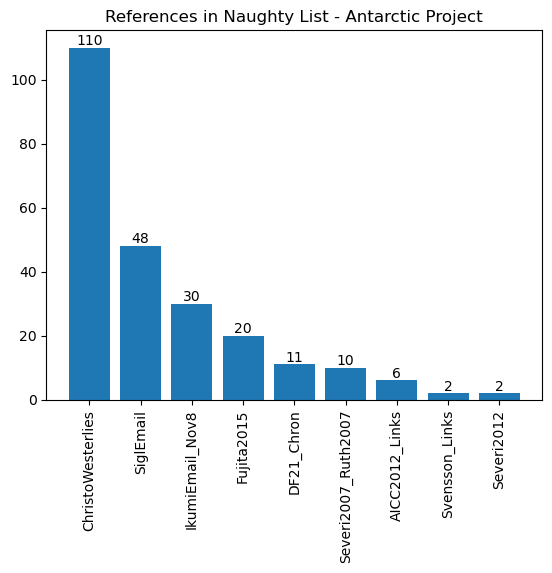

In [13]:
#reference bar plot

refs = []
for idx in naughty_list:
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        refs.append(r)

counts = Counter(refs) #this counts the number of occurrences of each reference in the refs list

sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"References in Naughty List - {project} Project")
plt.show()

154


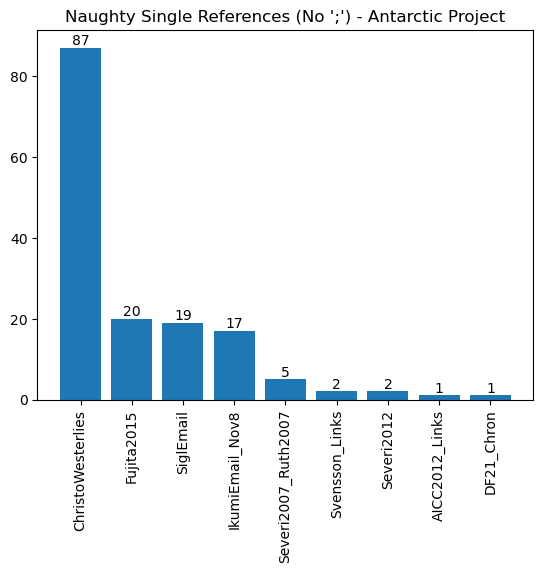

In [14]:
# reference bar plot (only single references — no ';')

full_refs_grab = []
for idx in naughty_list:
    ref = get_reference(idx)
    full_refs_grab.append(ref)

single_refs = [r for r in full_refs_grab if ";" not in r]

print(len(single_refs))
counts_single = Counter(single_refs)

sorted_items = sorted(counts_single.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"Naughty Single References (No ';') - {project} Project")
plt.show()

41


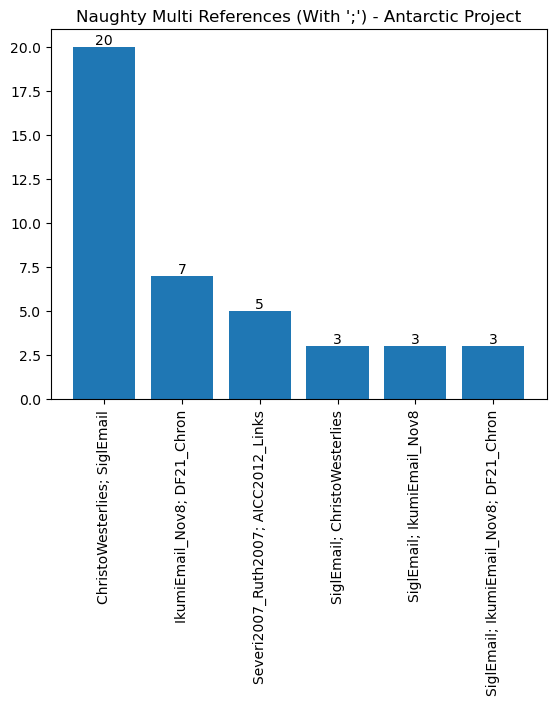

In [15]:
# reference bar plot (only multi references — ';')

full_refs_grab = []
for idx in naughty_list:
    ref = get_reference(idx)
    full_refs_grab.append(ref)

single_refs = [r for r in full_refs_grab if ";" in r]

print(len(single_refs))
counts_single = Counter(single_refs)

sorted_items = sorted(counts_single.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

plt.figure()
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title(f"Naughty Multi References (With ';') - {project} Project")
plt.show()

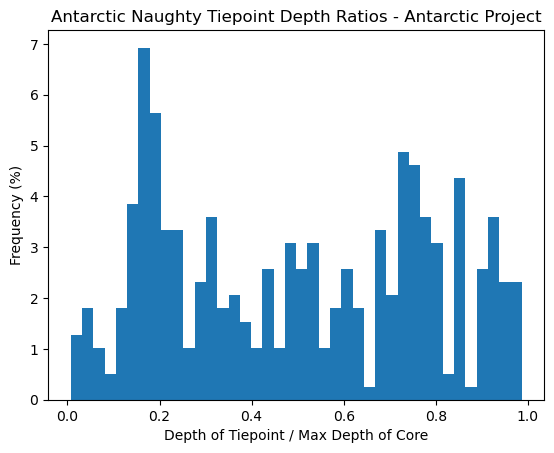

In [16]:
# depths ratio bar plot

if project == 'Antarctic':
    depths = data['max_depths']
    depth_ratio = []
    order = ['EDC', 'WDC', 'EDML', 'DF', 'TALDICE']
    for idx in naughty_list:
        ref = get_reference(idx)
        cores_row = big_table.loc[idx].dropna()
        core1 = cores_row.index[0].split("-")[0]
        core2 = cores_row.index[0].split("-")[1].split("_")[0]
        core1_depth = get_depth(core1, idx)
        core2_depth = get_depth(core2, idx)
        if core1 in order and core2 in order:
            core1_order = order.index(core1)
            core2_order = order.index(core2)
            core1_max = depths[core1_order]
            core2_max = depths[core2_order]
            
        ratio1 = core1_depth/core1_max
        ratio2 = core2_depth/core2_max
        for r in (ratio1, ratio2):
            depth_ratio.append(r)


    from matplotlib.ticker import PercentFormatter


    plt.figure()
    bars = plt.hist(depth_ratio, bins=40, weights=100*np.ones(len(depth_ratio)) / len(depth_ratio))

    plt.xticks(rotation=0)
    plt.xlabel("Depth of Tiepoint / Max Depth of Core")
    plt.ylabel("Frequency (%)")
    plt.title(f"Antarctic Naughty Tiepoint Depth Ratios - {project} Project")
    plt.show()
else:
    print("Depth ratio plot only available for Antarctic project, since it requires max depth data for each core.")

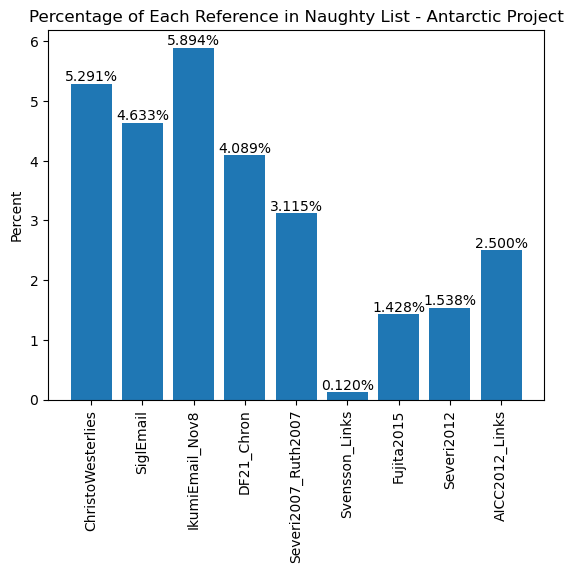

In [17]:
all_refs = []
for idx, row in big_table.iterrows():
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        all_refs.append(r)

all_counts = Counter(all_refs)
all_dict = dict(all_counts)

naughty_refs = []
for idx in naughty_list:
    ref = get_reference(idx)
    r_split = ref.split("; ")
    for r in r_split:
        naughty_refs.append(r)

naughty_counts = Counter(naughty_refs)
naughty_dict = dict(naughty_counts)

names = []
percentages = []
for c, v in naughty_dict.items():
    names.append(c)
    percentages.append(100*v/all_dict[f'{c}'])

bars = plt.bar(names, percentages)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.ylabel("Percent")
plt.title(f"Percentage of Each Reference in Naughty List - {project} Project")
plt.show()
    